## Exercise 10
È stato implementato il supporto $MPI$ al codice sviluppato nell’esercizio $9$: si eseguono $9$ ricerche genetiche parallele che, ogni $N_{migr} = 30$ generazioni, scambiano casualmente le migliori rotte. In questo caso, il problema del *Travelling Salesman* è applicato all’ottimizzazione del percorso tra 110 capitali di provincia italiane.

Si ottengono i seguenti grafici:
<p style="display: flex; justify-content: space-between;">
    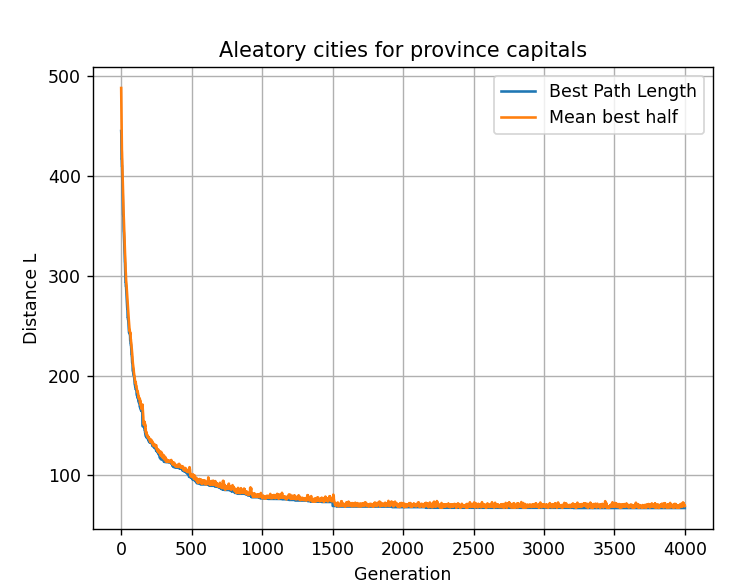
    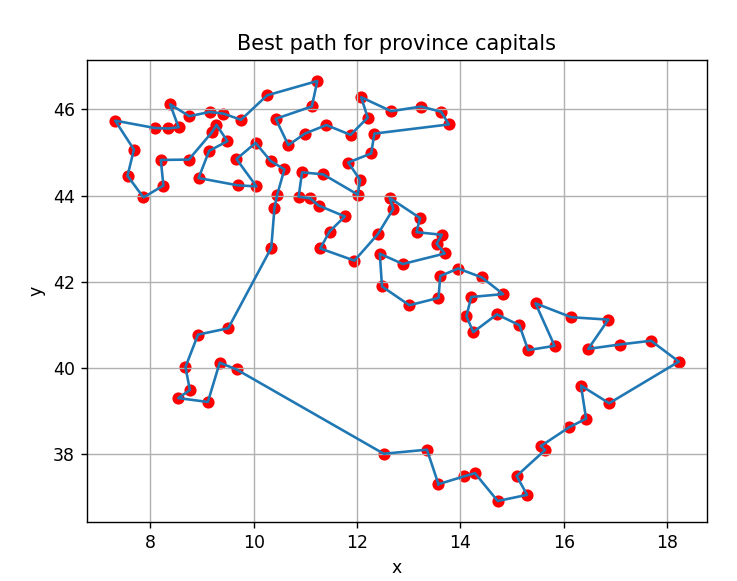
</p>

In alternativa, eseguendo la simulazione senza $N_{migr}$, cioè lasciando evolvere ciascuna delle 9 ricerche in modo indipendente, si ottengono i seguenti risultati:
<p style="display: flex; justify-content: space-between;">
    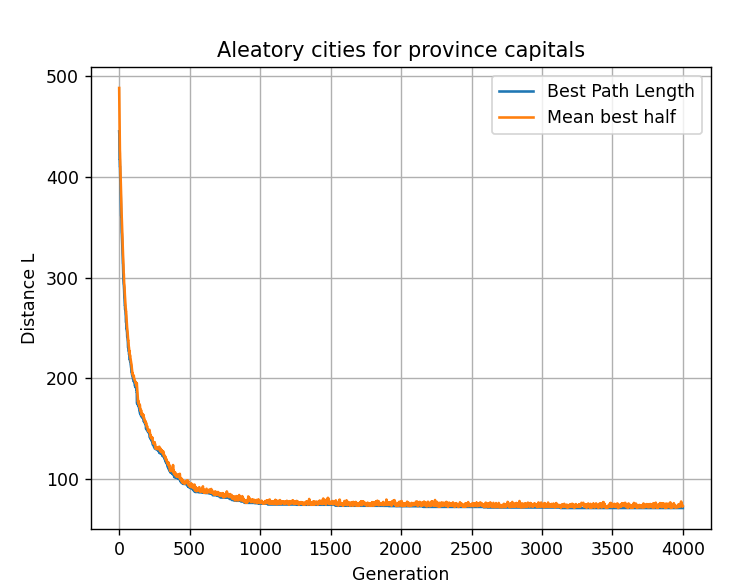
    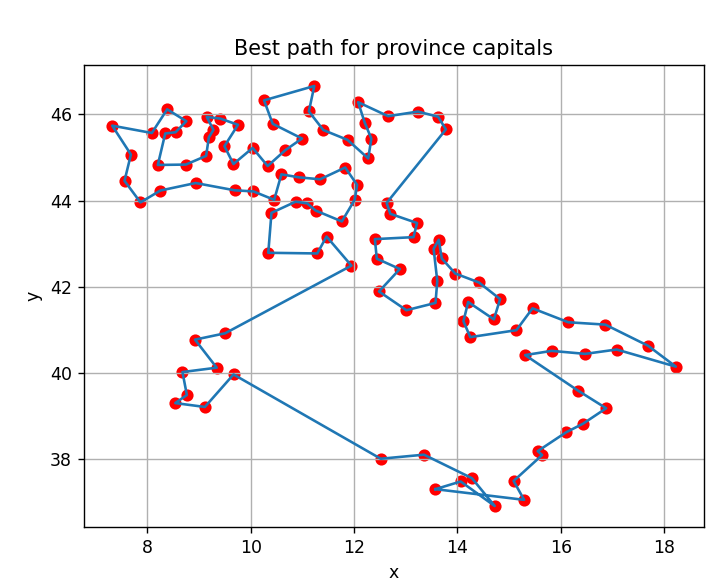
</p>

La differenza tra i due casi è relativamente piccola, poiché i valori di $N$ e $M$ sono sufficientemente elevati da permettere alle singole popolazioni di convergere verso soluzioni quasi ottimali anche senza comunicazione. Tuttavia, nel caso con $N_{migr}$ si osserva una maggiore efficienza globale: l’algoritmo raggiunge una minimizzazione del percorso più stabile e robusta, con traiettorie che evitano incroci in modo più sistematico rispetto al caso senza migrazione.

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from mpi4py import MPI

"""Cost function: total length"""
def L(vect, c):
    d = 0
    for i in range(len(vect) - 1):
        d += math.sqrt((c[vect[i+1]][0] - c[vect[i]][0])**2+
                      (c[vect[i+1]][1] - c[vect[i]][1])**2)      # |c(i+1) - c(i)|^2
    d += math.sqrt((c[vect[-1]][0] - c[vect[0]][0])**2 +
                   (c[vect[-1]][1] - c[vect[0]][1])**2)         # Traveler returns home
    return d

"""Verification function"""
def check(vect, N):
    return (len(vect)==len(np.unique(vect))==N) and (vect[0]==0)

"""Creation of the initial population"""
def initial_pob(N, M):
    p = np.zeros((M, N), dtype=int)
    p1 = np.arange(N)
    for i in range(M):
        v_i = p1.copy() 
        np.random.shuffle(v_i[1:])
        p[i] = v_i
    return p

"""Compute Fitness, path length"""
def Fitness(pob, c):
    fit = np.zeros(len(pob))
    for m in range(len(pob)):
        fit[m] = L(pob[m], c)
    return fit

"""Selection favoring better cities"""
def selection(M, p):
    r = np.random.rand()
    return int(M*(r**p))

# Mutation operators
"""Swap two cities"""
def mut_change(rute):
    pos1, pos2 = np.random.choice(range(1, len(rute)), 2, replace=False)
    rute[pos1], rute[pos2] = rute[pos2], rute[pos1]       # Change the routes
    return rute
"""Inverse a secuence of cities""" 
def mut_inv(rute):
    pos1, pos2 = sorted(np.random.choice(range(1, len(rute)), 2, replace=False))
    rute[pos1:pos2] = rute[pos1:pos2][::-1]               # Invert the order
    return rute
"""Shift a block of cities"""
def mut_shift(rute):
    N = len(rute)
    m = np.random.randint(1, N-2)                   # Length of the block
    pos1 = np.random.randint(1, N-m)                # Starting position of the move
    shift = np.random.randint(1, N-pos1-m+1)
    block = rute[pos1:pos1 + m].copy()
    rute[pos1:pos1 + shift] = rute[pos1+m:pos1+m+shift]
    rute[pos1+shift:pos1+m+shift] = block
    return rute
"""Swap two blocks of cities"""
def mut_blocks(rute):
    N = len(rute)
    m = np.random.randint(1, N//2)                  # Length of the block
    pos1 = np.random.randint(1, N-2*m+1)            
    pos2 = np.random.randint(pos1+m, N-m+1)
    block = rute[pos1:pos1+m].copy()
    rute[pos1:pos1+m] = rute[pos2:pos2+m]
    rute[pos2:pos2+m] = block
    return rute
"""Apply all the mutations with a 0.1 probability each"""
def mutations(rute):
    if np.random.rand() < 0.1:
        mut_shift(rute)
    if np.random.rand() < 0.1:
        mut_inv(rute)
    if np.random.rand() < 0.1:
        mut_change(rute)
    if np.random.rand() < 0.1:
        mut_blocks(rute)
    return rute

"""Crossover between two individuals"""
def crossover(mom, dad):
    N = len(mom)
    son1 = np.zeros(N, dtype=int)
    son2 = np.zeros(N, dtype=int)
    cut = np.random.randint(1, N)
    son1[:cut] = mom[:cut]
    son2[:cut] = dad[:cut]
    k = cut
    for c in dad:
        if c not in son1[:cut]:
            son1[k] = c
            k += 1
    k = cut
    for c in mom:
        if c not in son2[:cut]:
            son2[k] = c
            k += 1
    return son1, son2

"""Creates a new generation"""
def new_generation(pob,c):
    M = len(pob)
    new_pob = []
    while len(new_pob) < M:       # repeat till fill the poblation
        mother = pob[selection(M, 2)].copy()
        father = pob[selection(M, 2)].copy()
        if np.random.rand() < 0.6:
            son1, son2 = crossover(mother, father)
        else:
            son1, son2 = mother, father
        son1 = mutations(son1)
        son2 = mutations(son2)
        # Verify if the sons meet the requirements
        if not check(son1, N) or not check(son2, N):
            raise ValueError("Incorrected values for the sons creation")
        new_pob.append(son1)
        if len(new_pob) < M:
            new_pob.append(son2)
    return np.array(new_pob)
    
"""GENETIC ALGORITHM"""
def AG(c, M, N, GEN, title, N_migr, size, comm, rank):
    pob = initial_pob(N, M)           # Poblation: M vectors of length N
    best_rute = np.zeros(GEN)           # Traveler route
    best_mean = np.zeros(GEN)           # Traveler route

    for g in range(GEN):
        fit = Fitness(pob, c)             # Fitness
        # Re-ordenate from worst to best
        index = np.argsort(fit)
        fit = fit[index]
        pob = pob[index]
        
        best_rute[g] = fit[0]
        best_mean[g] = np.mean(np.sort(fit)[:len(fit)//2])

        if g % N_migr == 0 and g > 0:
            bests = np.zeros((size, N),dtype=int)
            best = pob[0].copy()               # Extract and send the best route
            comm.Gather(best, bests, root=0)   # All the bests remain in the first continent
            if rank==0:
                np.random.shuffle(bests)       # Aleatory mixing
            comm.Bcast(bests, root=0)          # Best sending
            pob[-1] = bests[rank]              # Each continent keeps one best
            
        if g < GEN -1:
            pob = new_generation(pob, c)
    
    if (rank ==0):                              # Just plot 1 continent           
        # Evolution plot
        plt.figure()
        plt.plot(best_rute, label="Best Path Length")
        plt.plot(best_mean, label="Mean best half")
        plt.xlabel('Generation')
        plt.ylabel('Distance L')
        plt.title(f'Aleatory cities {title}')
        plt.legend()
        plt.grid(True)
        plt.show()
    
        # Path plot
        best_rute_index = pob[0]
        final_rute = np.append(best_rute_index, best_rute_index[0]) # Ends at the start
        plt.figure()
        plt.plot(c[final_rute, 0], c[final_rute, 1])
        plt.scatter(c[:,0], c[:,1], color='red')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'Best path {title}')
        plt.grid(True)
        plt.show()

if __name__ == "__main__":
    # FINAL ALGORITHM    
    N = 110                           # Number of provence capitals
    M = 150                           # Poblation length
    GEN = 4000                        # Generation
    N_migr = 5000
    
    comm = MPI.COMM_WORLD
    size = comm.Get_size()
    rank = comm.Get_rank()
    np.random.seed(rank)

    c = np.zeros((N, 2))       # Positions of each city
    if rank == 0:              # The first continent initialices the poblation
        caps = np.loadtxt(r"cap_prov_ita.dat")
        c = caps.copy()
    
    # All the continents start with the same poblation
    comm.Bcast(c, root=0)

    AG(c, M, N, GEN, "for province capitals", N_migr, size, comm, rank)